Task-1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [3]:
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Matplotlib Version:", plt.matplotlib.__version__)
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

NumPy Version: 2.3.5
Pandas Version: 2.3.3
Matplotlib Version: 3.10.6
PyTorch Version: 2.11.0
Torchvision Version: 0.26.0


In [4]:
print("MPS Available (Mac GPU):", torch.backends.mps.is_available())

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU ")
else:
    device = torch.device("cpu")
    print("Running on CPU")

print("Selected Device:", device)

# This system uses Apple M2 chip, which does not support CUDA.
# PyTorch uses MPS (Metal Performance Shaders) for GPU acceleration.
# GPU (MPS/CUDA) is faster than CPU because it performs parallel computations.
# On GPU, training can be significantly faster and allows larger batch sizes.

MPS Available (Mac GPU): True
Using Apple MPS GPU
Selected Device: mps


In [5]:
# Reproducibility

torch.manual_seed(42) # torch.manual_seed → controls model weights and operations
np.random.seed(42) # numpy seed → controls NumPy randomness
random.seed(42) # random.seed → controls Python randomness

if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

In [16]:
from torchvision.datasets import MNIST, CIFAR10

mnist_train = MNIST(root="./data", train=True, download=True)
mnist_test = MNIST(root="./data", train=False, download=True)

cifar_train = CIFAR10(root="./data", train=True, download=True)
cifar_test = CIFAR10(root="./data", train=False, download=True)

In [17]:
import numpy as np

# MNIST
x_train_m = mnist_train.data.numpy()
y_train_m = mnist_train.targets.numpy()

x_test_m = mnist_test.data.numpy()
y_test_m = mnist_test.targets.numpy()

# CIFAR-10
x_train_c = np.array(cifar_train.data)
y_train_c = np.array(cifar_train.targets)

x_test_c = np.array(cifar_test.data)
y_test_c = np.array(cifar_test.targets)

In [18]:
print("MNIST Train Shape:", x_train_m.shape)
print("MNIST Test Shape:", x_test_m.shape)

print("CIFAR Train Shape:", x_train_c.shape)
print("CIFAR Test Shape:", x_test_c.shape)

MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)


In [19]:
print("\nMNIST dtype:", x_train_m.dtype)
print("CIFAR dtype:", x_train_c.dtype)


MNIST dtype: uint8
CIFAR dtype: uint8


In [20]:
print("\nMNIST range:", x_train_m.min(), x_train_m.max())
print("CIFAR range:", x_train_c.min(), x_train_c.max())


MNIST range: 0 255
CIFAR range: 0 255


In [21]:
unique, counts = np.unique(y_train_m, return_counts=True)
print("MNIST Class Distribution:")
print(dict(zip(unique, counts)))  
#MNIST class distribution is approximately balanced
# each class has around 6000 samples

MNIST Class Distribution:
{np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}


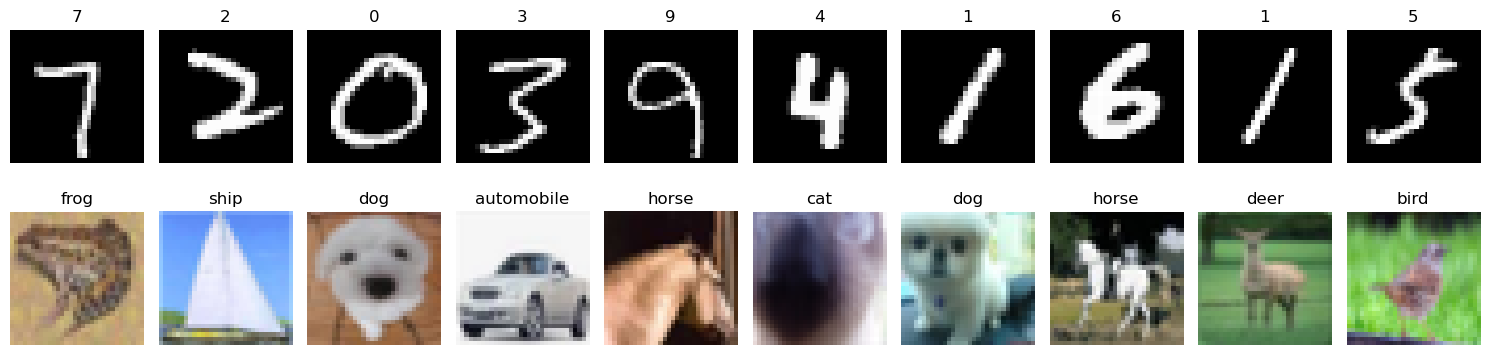

In [22]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# MNIST row
for i in range(10):
    idx = np.random.randint(len(x_train_m))
    axes[0, i].imshow(x_train_m[idx], cmap='gray')
    axes[0, i].set_title(str(y_train_m[idx]))
    axes[0, i].axis('off')

# CIFAR row
classes = cifar_train.classes
for i in range(10):
    idx = np.random.randint(len(x_train_c))
    axes[1, i].imshow(x_train_c[idx])
    axes[1, i].set_title(classes[y_train_c[idx]])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [31]:
def preprocessfunc(x, y, is_mnist=False):

    print("BEFORE PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    
    # Normalize to [0, 1]
    x = x.astype(np.float32) / 255.0  # Pixel values are scaled to the range [0,1] by dividing by 255.0.
     # This helps in faster convergence and stable training of neural networks.
    
    # Reshape MNIST (add channel dimension)
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
    
    # One-hot encode labels(Labels are converted into vectors of length 10, where the correct class index is 1 and others are 0.)
    y_onehot = np.eye(10)[y]
    
    print("\nAFTER PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    print("Label sample (one-hot):", y_onehot[0])
    
    return x, y_onehot

In [32]:
x_train_m_p, y_train_m_p = preprocessfunc(x_train_m, y_train_m, is_mnist=True)

BEFORE PREPROCESSING
Shape: (60000, 28, 28)
Dtype: uint8
Min/Max: 0 255
Sample values: [0 0 0 0 0 0 0 0 0 0]

AFTER PREPROCESSING
Shape: (60000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Label sample (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [33]:
x_train_c_p, y_train_c_p = preprocessfunc(x_train_c, y_train_c, is_mnist=False)

BEFORE PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: uint8
Min/Max: 0 255
Sample values: [59 62 63 43 46 45 50 48 43 68]

AFTER PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0.23137255 0.24313726 0.24705882 0.16862746 0.18039216 0.1764706
 0.19607843 0.1882353  0.16862746 0.26666668]
Label sample (one-hot): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [34]:
cifar_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(32, scale=(0.9, 1.1)),
    transforms.ToTensor()
])

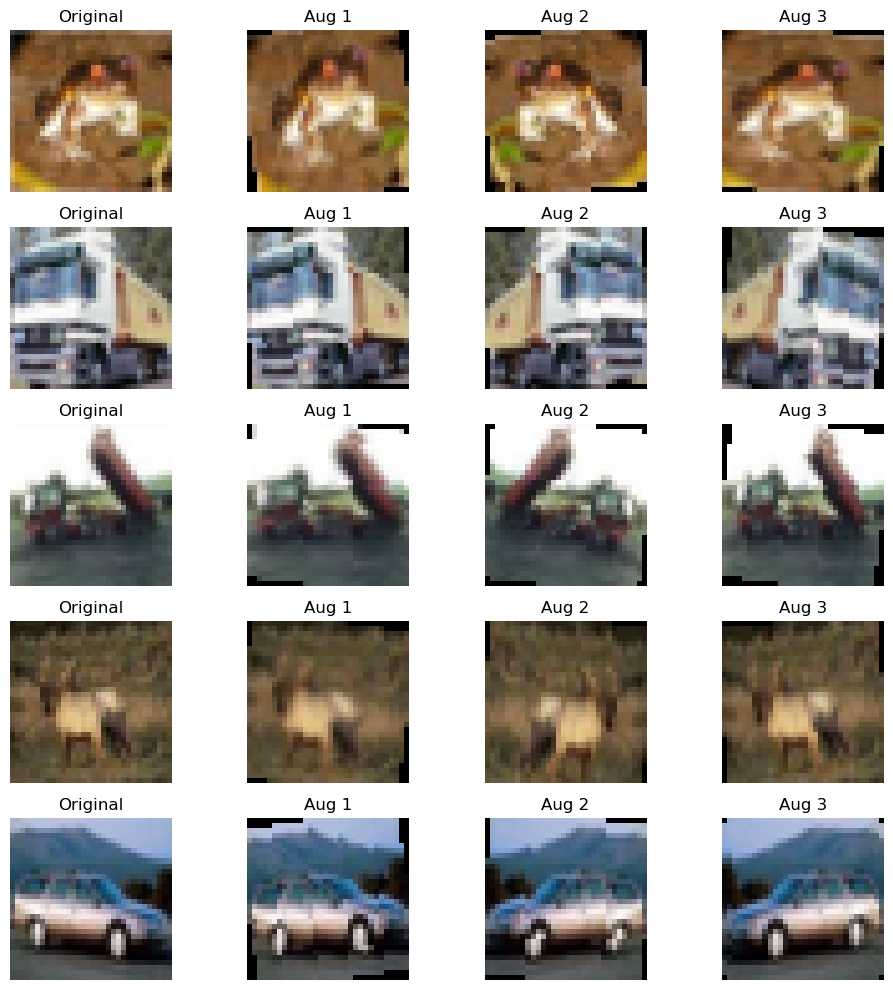

In [35]:
fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for i in range(5):
    img = x_train_c[i]

    # Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Augmented
    for j in range(1, 4):
        aug_img = cifar_transform(img)
        aug_img = aug_img.permute(1, 2, 0)

        axes[i, j].imshow(aug_img)
        axes[i, j].set_title(f"Aug {j}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set to increase data diversity and improve the model’s ability to generalize. It introduces variations such as rotation, flipping, and zoom, which help reduce overfitting.

The validation and test sets must remain unchanged because they are used to evaluate the model on real, unseen data. Applying augmentation to them would distort the data distribution and result in biased or unreliable evaluation.

Augmentation must be label-preserving, meaning the transformation should not change the class of the image.

For MNIST : digits are sensitive to orientation. Transformations like horizontal flipping are not suitable because flipping a digit such as “6” may resemble a “9”, thereby changing its label. Therefore, only safe transformations like small rotations are applied.

For CIFAR-10 : objects such as animals and vehicles remain identifiable even after transformations like horizontal flipping, rotation, and zoom. Hence, these augmentations are valid and do not alter the class label.

Thus, different augmentation strategies are used for MNIST and CIFAR-10 to ensure that all transformations are label-preserving. This helps maintain data integrity while improving model generalization.

In [36]:
mnist_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),   # small rotation only
    transforms.ToTensor()
])

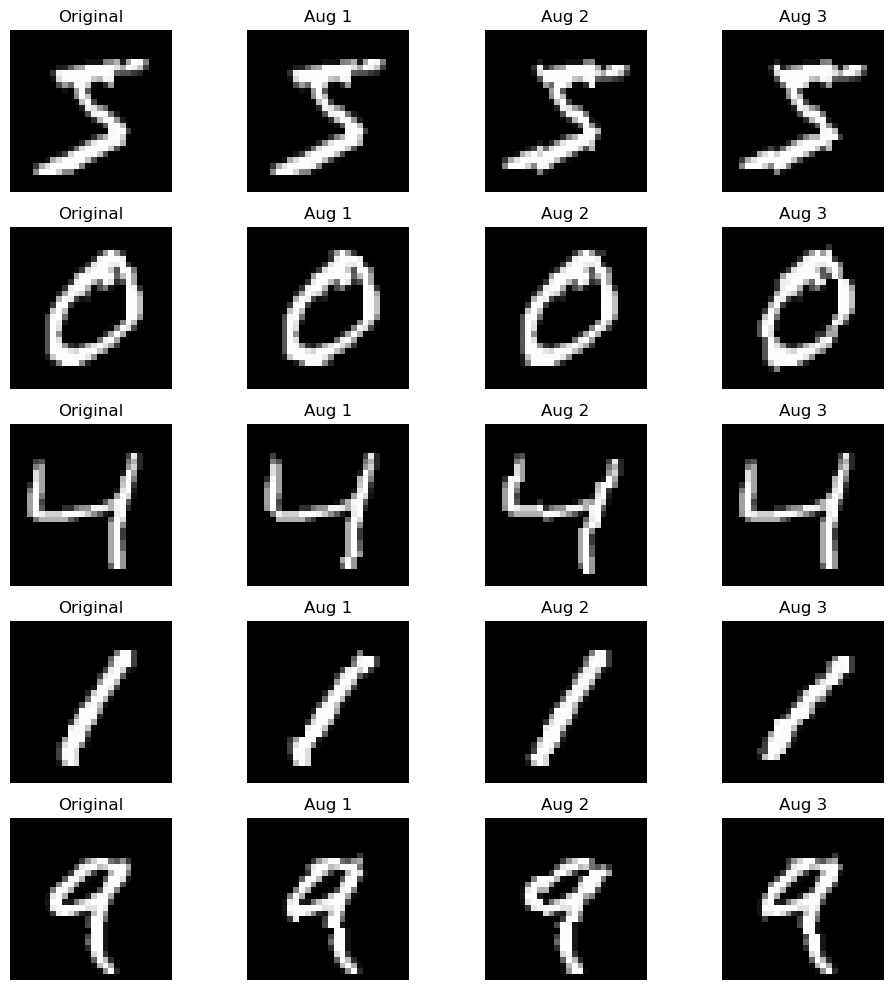

In [37]:
fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for i in range(5):
    img = x_train_m[i]   

    # Original
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Augmented versions
    for j in range(1, 4):
        aug_img = mnist_transform(img)   # apply transform
        aug_img = aug_img.squeeze()      # remove channel dim
        
        axes[i, j].imshow(aug_img, cmap='gray')
        axes[i, j].set_title(f"Aug {j}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("mnist_augmentation_demo.png")
plt.show()

ANALYSIS & REFLECTION QUESTIONS (Task-1)

1. The channel dimension C in a tensor of shape (N, H, W, C) represents the      number of feature channels or color components present in each image.
   N = number of images (batch size)
   H = height of image
   W = width of image
   C = number of channels

For a greyscale image, there is only one channel (C = 1).
This channel stores intensity values (brightness) for each pixel.

For an RGB image, there are three channels (C = 3): Red, Green & Blue channels 

2. To handle very large images (1024×1024) without running out of memory, the    following strategies can be used:

Batch Loading (DataLoader):
Instead of loading the entire dataset into memory, images are loaded in small batches during training. This reduces memory usage and allows efficient processing.

Patch-based Training:
Large images are divided into smaller patches (e.g., 256×256). The model is trained on these patches instead of the full image, significantly reducing memory requirements

Additionally, image resizing or downsampling can also be used to reduce resolution, but this may lead to loss of fine details.

3. Applying normalization to the test set using its own mean and standard        deviation is incorrect because it introduces data leakage.

The test set is supposed to represent unseen data. Using its statistics allows the model to indirectly gain information about the test distribution, leading to biased and overly optimistic evaluation results.

Instead, the test set must be normalized using the mean and standard deviation computed from the training set only, ensuring a fair and realistic evaluation.